# Constraint mapping across Market, Dayzer, Pano

Goal: figure out which entries refer to the same (facility, contingency) constraint across the three sources.

Mostly a text-normalization problem with a fuzzy fallback for what doesn't canonicalize cleanly.

In [1]:
import pandas as pd
import numpy as np
import re
from rapidfuzz import fuzz, process as rfprocess
from collections import defaultdict
from pathlib import Path
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

DATA = Path.cwd()

# tuned by looking at the resulting low-conf bucket
FUZZY_HIGH = 92
FUZZY_LOW  = 78
CTG_FUZZY  = 88
MAX_GROUP  = 200

In [2]:
market = pd.read_csv(DATA / "Market PJMISO constraint list.csv")
dayzer = pd.read_csv(DATA / "Dayzer PJMISO constraint list.csv")
pano   = pd.read_csv(DATA / "Pano PJMISO constraint list.csv")

market['market_id'] = range(len(market))
dayzer['dayzer_id'] = range(len(dayzer))
pano['pano_id']     = range(len(pano))

len(market), len(dayzer), len(pano)

(5230, 13813, 21963)

## Look at the data

In [3]:
market.head(3)

,CONSTRAINT,CONTINGENCY,TOZONE,REPORTEDNAME,CONSTRAINTID,CONTINGENCYID,market_id
0,NOTTINGH 230 KV NOTTINGHM 2-3 SER DEV,L500.CONASTONE-PEACHBOTTOM.5012,NaN,NOTTINGHM 2-3 SER DEV A 230 KV,10002384305,10002493264,0
1,LENOX 115 KV LENOX-NMESHOPP NML 1090,L230.ETOWANDA-HILLSIDE.2002 [NYISO],PENELEC,LENOX-NMESHOPP NML 1090 B 115 KV,10000566138,10001865201,1
2,EASTON 69 KV EAS-EMU,ACTUAL,DPL,EASTON 69 KV EAS-EMU,10004072634,10000680485,2


In [4]:
dayzer.head(3)

,CID,NAME,dayzer_id
0,1,Eastern Interface,0
1,2,Central Interface,1
2,3,Western Interface,2


In [5]:
pano.head(3)

,PID,Monitored Facility,Contingency Name,Earliest,Latest,pano_id
0,1,CHIC_AVE 138KV - PRAXAIR3 138KV (CHIC_AVE 138 ...,L765.Dumont-WiltonCenter.11215,2017-06-29 00:00:00-04:00,2026-04-28 23:00:00-04:00,0
1,2,177 BURN 345KV - MUNSTER2 345KV (177 BURN 345 ...,L765.Dumont-WiltonCenter.11215,2016-11-23 03:00:00-05:00,2026-04-28 23:00:00-04:00,1
2,3,CONASTON 500KV - CONASTON 230KV (CONASTON 500 ...,L500.Brighton-Conastone.5011,2021-02-17 06:00:00-05:00,2026-04-28 23:00:00-04:00,2


In [6]:
# Dayzer NAME splits FAC:CTG on ':'. Rows without ':' are interface aggregates (eg 'Eastern Interface').
dayzer['NAME'].str.contains(':').value_counts()

NAME
True     13174
False      639
Name: count, dtype: int64

In [7]:
# Pano has two facility formats: with a (SHORTCODE) parenthetical, and without.
pano['Monitored Facility'].str.contains(r'\(', regex=True).value_counts()

Monitored Facility
False    13250
True      8713
Name: count, dtype: int64

## Normalization

Stuff I needed to fix to get exact matches:

- voltage spacing: `138KV` / `138 KV` / `BOONETWN230 KV` / `230KVGRA-MANO`
- underscores as separators (Dayzer always, some Market rows, Pano format B)
- Market's `L/O ...` suffix — loop-out config that doesn't appear in the other sources
- short region/operator tags: `[NYISO]`, `(MEC)`, `(Sctnlz)`. Don't strip long parentheticals (those carry topology, eg `(MOROCCO-LULU-MILAN-MONROE)`)
- `BASE` = `ACTUAL` (Pano vs Market for the base case)
- trailing `_1_LN` / `_XF` section tags — Format-A parentheticals drop them, Format-B keeps them

L/O bit me twice before I noticed.

In [8]:
ABBREV = {'ELECTRICJCT': 'ELECTRICJUNCTION'}
DOT_CTG = re.compile(r'^(L\d+\.|\d+/\d+\.)', re.IGNORECASE)
TAG_TRAIL = re.compile(r'\s*[\(\[]([^\)\]]{1,12})[\)\]]\s*$')


def norm_voltage(s):
    # insert space when voltage is glued to letters on either side, then collapse '138 KV'
    s = re.sub(r'([A-Za-z0-9])(?=(?:69|115|138|161|230|345|500|765)\s*KV)', r'\1 ', s, flags=re.IGNORECASE)
    s = re.sub(r'(\d+)\s*KV(?=[A-Za-z0-9])', r'\1 KV ', s, flags=re.IGNORECASE)
    s = re.sub(r'(\d+)\s*KV\b', r'\1 KV', s, flags=re.IGNORECASE)
    return s


def collapse_ws(s):
    return re.sub(r'\s+', ' ', s).strip()


def strip_lo(s):
    return re.sub(r'\s+L/O\s+.*$', '', s, flags=re.IGNORECASE)


def expand_abbrev(seg):
    for a, full in ABBREV.items():
        seg = re.sub(r'\b' + a + r'\b', full, seg, flags=re.IGNORECASE)
    return seg


def strip_tag(s):
    # short trailing (...) or [...] only; loop in case there are two
    prev = None
    while prev != s:
        prev = s
        s = TAG_TRAIL.sub('', s).strip()
    return s


def norm_ctg(raw):
    s = str(raw).strip().upper()
    if s in ('BASE', '', 'NAN', 'NONE', 'NAT'):
        return 'ACTUAL'
    s = strip_tag(s)
    s = collapse_ws(s)
    if DOT_CTG.match(s):
        parts = []
        for p in s.split('.'):
            p = re.sub(r'\s*-\s*', '-', p)
            p = expand_abbrev(p)
            p = re.sub(r'(?<=[A-Z0-9])\s+(?=[A-Z0-9])', '', p)
            parts.append(p)
        return '.'.join(parts)
    return s


def norm_fac(raw, source='market'):
    s = str(raw).strip().upper().replace('_', ' ')
    if source == 'market':
        s = strip_lo(s)
    s = norm_voltage(s)
    s = collapse_ws(s)
    s = re.sub(r'\s+(?:\d+\s+)?(?:LN|XF)\s*$', '', s, flags=re.IGNORECASE)
    return collapse_ws(s)


def pano_paren(raw):
    m = re.search(r'\(([^)]+)\)\s*$', str(raw))
    if m:
        return m.group(1).strip(), True
    return str(raw).strip(), False


def mkkey(f, c):
    return f"{f}||{c}"


# sanity check before moving on
print(norm_ctg('BASE'))
print(norm_ctg('L345.OAKGROVE-LOUISA (MEC)'))
print(norm_fac('GRACETON_230KVGRA-MANO_1_LN'))
print(norm_fac('CHICAGO-PRAXAIR3 138 KV L/O WILTON CENTER-DUMONT 765 KV'))

ACTUAL
L345.OAKGROVE-LOUISA
GRACETON 230 KV GRA-MANO
CHICAGO-PRAXAIR3 138 KV


## Parse each source

In [9]:
def parse_dz(name):
    s = str(name)
    if ':' in s:
        i = s.index(':')
        return s[:i].strip(), s[i+1:].strip(), False
    return s.strip(), None, True

parsed = dayzer['NAME'].apply(parse_dz)
dayzer['dz_fac']   = [x[0] for x in parsed]
dayzer['dz_ctg']   = [x[1] for x in parsed]
dayzer['is_iface'] = [x[2] for x in parsed]

dz_line  = dayzer[~dayzer['is_iface']].copy().reset_index(drop=True)
dz_iface = dayzer[ dayzer['is_iface']].copy().reset_index(drop=True)

dz_line['nfac'] = dz_line['dz_fac'].apply(lambda s: norm_fac(s, 'dayzer'))
dz_line['nctg'] = dz_line['dz_ctg'].apply(norm_ctg)
dz_line['key']  = dz_line.apply(lambda r: mkkey(r.nfac, r.nctg), axis=1)

len(dz_line), len(dz_iface)

(13174, 639)

In [10]:
parsed = pano['Monitored Facility'].apply(pano_paren)
pano['pshort'] = [x[0] for x in parsed]
pano['fmtA']   = [x[1] for x in parsed]

def npano(r):
    return norm_fac(r['pshort'], 'market' if r['fmtA'] else 'pano_b')

pano['nfac'] = pano.apply(npano, axis=1)
pano['nctg'] = pano['Contingency Name'].apply(norm_ctg)
pano['key']  = pano.apply(lambda r: mkkey(r.nfac, r.nctg), axis=1)

pano['fmtA'].value_counts()

fmtA
False    13271
True      8692
Name: count, dtype: int64

In [11]:
market['nfac']     = market['CONSTRAINT'].apply(lambda s: norm_fac(s, 'market'))
market['nctg']     = market['CONTINGENCY'].apply(norm_ctg)
market['key']      = market.apply(lambda r: mkkey(r.nfac, r.nctg), axis=1)
# REPORTEDNAME catches some Market rows that CONSTRAINT misses
market['nfac_rpt'] = market['REPORTEDNAME'].apply(lambda s: norm_fac(s, 'market'))
market['key_rpt']  = market.apply(lambda r: mkkey(r.nfac_rpt, r.nctg), axis=1)

## Pass 1 — exact key match

Inner-join on `facility||contingency`. Falls back to REPORTEDNAME for Market rows the primary key misses.

In [12]:
# market <-> pano
mp1 = market.merge(
    pano[['pano_id','key','Monitored Facility','Contingency Name']],
    on='key', how='inner'
)[['market_id','pano_id','CONSTRAINT','CONTINGENCY','REPORTEDNAME','Monitored Facility','Contingency Name']]
mp1['p_method'] = 'exact'

seen = set(mp1['market_id'])
mp2 = (market[~market['market_id'].isin(seen)]
       .merge(pano[['pano_id','key','Monitored Facility','Contingency Name']],
              left_on='key_rpt', right_on='key', how='inner')
       [['market_id','pano_id','CONSTRAINT','CONTINGENCY','REPORTEDNAME','Monitored Facility','Contingency Name']])
mp2['p_method'] = 'exact_rpt'

mp_exact = pd.concat([mp1, mp2], ignore_index=True)
print(f"market<->pano exact: {len(mp_exact)} ({len(mp_exact)/len(market):.1%})")

market<->pano exact: 4786 (91.5%)


In [13]:
# market <-> dayzer
md1 = market.merge(
    dz_line[['dayzer_id','key','CID','NAME']],
    on='key', how='inner'
)[['market_id','dayzer_id','CID','NAME','CONSTRAINT','CONTINGENCY','REPORTEDNAME']]
md1['d_method'] = 'exact'

seen_d = set(md1['market_id'])
md2 = (market[~market['market_id'].isin(seen_d)]
       .merge(dz_line[['dayzer_id','key','CID','NAME']],
              left_on='key_rpt', right_on='key', how='inner')
       [['market_id','dayzer_id','CID','NAME','CONSTRAINT','CONTINGENCY','REPORTEDNAME']])
md2['d_method'] = 'exact_rpt'

md_exact = pd.concat([md1, md2], ignore_index=True)
print(f"market<->dayzer exact: {len(md_exact)} ({len(md_exact)/len(market):.1%})")

market<->dayzer exact: 3880 (74.2%)


## Pass 2 — fuzzy facility within matching contingency

Group candidates by normalized contingency, then fuzzy-match facility inside each group. Way smaller comparison space than all-pairs.

In [14]:
def ctg_index(df, fac_col, id_col):
    idx = defaultdict(list)
    for ctg, g in df.groupby('nctg', sort=False):
        idx[ctg] = list(zip(g[id_col].tolist(), g[fac_col].tolist()))
    return idx

mp_set = set(mp_exact['market_id'])
md_set = set(md_exact['market_id'])
p_set  = set(mp_exact['pano_id'])
d_set  = set(md_exact['dayzer_id'])

unmkt_p = market[~market['market_id'].isin(mp_set)]
unmkt_d = market[~market['market_id'].isin(md_set)]
unpan   = pano[~pano['pano_id'].isin(p_set)]
undz    = dz_line[~dz_line['dayzer_id'].isin(d_set)]

p_idx = ctg_index(unpan, 'nfac', 'pano_id')
d_idx = ctg_index(undz,  'nfac', 'dayzer_id')

print(f"still unmatched: {len(unmkt_p)} mkt/pano, {len(unmkt_d)} mkt/dayzer")

still unmatched: 697 mkt/pano, 1354 mkt/dayzer


In [15]:
def fuzzy_within_ctg(mkt, idx, id_col, hi, lo, cap):
    out = []
    for r in mkt.itertuples(index=False):
        cands = idx.get(r.nctg, [])
        if not cands:
            continue
        cands = cands[:cap]
        ids   = [c[0] for c in cands]
        facs  = [c[1] for c in cands]
        best  = rfprocess.extractOne(r.nfac, facs, scorer=fuzz.token_sort_ratio, score_cutoff=lo)
        if best:
            _, score, i = best
            out.append({
                'market_id': r.market_id,
                id_col: ids[i],
                'method': 'fuzzy_high' if score >= hi else 'fuzzy_low',
                'score': float(score) / 100,
            })
    return out

mp_p2 = fuzzy_within_ctg(unmkt_p, p_idx, 'pano_id',   FUZZY_HIGH, FUZZY_LOW, MAX_GROUP)
md_p2 = fuzzy_within_ctg(unmkt_d, d_idx, 'dayzer_id', FUZZY_HIGH, FUZZY_LOW, MAX_GROUP)

if mp_p2:
    mp_p2 = pd.DataFrame(mp_p2).rename(columns={'method':'p_method','score':'p_score'})
else:
    mp_p2 = pd.DataFrame(columns=['market_id','pano_id','p_method','p_score'])
if md_p2:
    md_p2 = pd.DataFrame(md_p2).rename(columns={'method':'d_method','score':'d_score'})
else:
    md_p2 = pd.DataFrame(columns=['market_id','dayzer_id','d_method','d_score'])

mp_set |= set(mp_p2['market_id'])
md_set |= set(md_p2['market_id'])
p_set  |= set(mp_p2['pano_id'])
d_set  |= set(md_p2['dayzer_id'])

print(f"pass 2: +{len(mp_p2)} pano, +{len(md_p2)} dayzer")

pass 2: +71 pano, +51 dayzer


## Pass 3 — double fuzzy

For what's left, fuzz the contingency too — top-5 contingencies by character ratio, then facility fuzzy within each.

In [16]:
def double_fuzzy(mkt, pool, ctg_pool, id_col, c_thresh, f_thresh, k=5):
    by_ctg = defaultdict(list)
    for r in pool.itertuples(index=False):
        by_ctg[r.nctg].append((getattr(r, id_col), r.nfac))

    out = []
    for r in mkt.itertuples(index=False):
        cands = rfprocess.extract(r.nctg, ctg_pool, scorer=fuzz.ratio, limit=k, score_cutoff=c_thresh)
        best = None
        for ctg, cs, _ in cands:
            grp = by_ctg.get(ctg, [])
            if not grp: continue
            ids  = [x[0] for x in grp]
            facs = [x[1] for x in grp]
            res = rfprocess.extractOne(r.nfac, facs, scorer=fuzz.token_sort_ratio, score_cutoff=f_thresh)
            if res:
                _, fs, i = res
                combined = (cs + fs) / 200.0
                if best is None or combined > best['score']:
                    best = {'market_id': r.market_id, id_col: ids[i], 'score': combined}
        if best:
            out.append(best)
    return out

rest_p = market[~market['market_id'].isin(mp_set)]
rest_d = market[~market['market_id'].isin(md_set)]
pool_p = pano[~pano['pano_id'].isin(p_set)]
pool_d = dz_line[~dz_line['dayzer_id'].isin(d_set)]

mp_p3 = double_fuzzy(rest_p, pool_p, pool_p['nctg'].unique().tolist(), 'pano_id',   CTG_FUZZY, FUZZY_LOW)
md_p3 = double_fuzzy(rest_d, pool_d, pool_d['nctg'].unique().tolist(), 'dayzer_id', CTG_FUZZY, FUZZY_LOW)

if mp_p3:
    mp_p3 = pd.DataFrame(mp_p3).assign(p_method='fuzzy_double').rename(columns={'score':'p_score'})
else:
    mp_p3 = pd.DataFrame(columns=['market_id','pano_id','p_method','p_score'])
if md_p3:
    md_p3 = pd.DataFrame(md_p3).assign(d_method='fuzzy_double').rename(columns={'score':'d_score'})
else:
    md_p3 = pd.DataFrame(columns=['market_id','dayzer_id','d_method','d_score'])

print(f"pass 3: +{len(mp_p3)} pano, +{len(md_p3)} dayzer")

pass 3: +15 pano, +78 dayzer


## Pass 4 — Dayzer interface entries

The rows without `:` are aggregates like 'Eastern Interface' — no individual line counterpart. Soft-match against Market REPORTEDNAME for a hint.

In [17]:
mkt_rpt = market['nfac_rpt'].tolist()
mkt_ids = market['market_id'].tolist()
iface = []
for _, row in dz_iface.iterrows():
    nm  = norm_fac(row['NAME'], 'dayzer')
    res = rfprocess.extractOne(nm, mkt_rpt, scorer=fuzz.token_set_ratio, score_cutoff=90)
    if res:
        _, sc, i = res
        iface.append({'dayzer_id': row['dayzer_id'], 'CID': row['CID'], 'NAME': row['NAME'],
                      'market_id': mkt_ids[i], 'd_method': 'interface_hint', 'd_score': sc/100})
    else:
        iface.append({'dayzer_id': row['dayzer_id'], 'CID': row['CID'], 'NAME': row['NAME'],
                      'market_id': None, 'd_method': 'interface_no_match', 'd_score': 0.0})

iface_df = pd.DataFrame(iface)
iface_df['d_method'].value_counts()

d_method
interface_no_match    380
interface_hint        259
Name: count, dtype: int64

## Combine + export

In [18]:
all_mp = pd.concat([
    mp_exact[['market_id','pano_id','p_method']].assign(p_score=1.0),
    mp_p2[['market_id','pano_id','p_method','p_score']],
    mp_p3[['market_id','pano_id','p_method','p_score']],
], ignore_index=True).sort_values('p_score', ascending=False).drop_duplicates('market_id', keep='first')

all_md = pd.concat([
    md_exact[['market_id','dayzer_id','d_method']].assign(d_score=1.0),
    md_p2[['market_id','dayzer_id','d_method','d_score']],
    md_p3[['market_id','dayzer_id','d_method','d_score']],
], ignore_index=True).sort_values('d_score', ascending=False).drop_duplicates('market_id', keep='first')

len(all_mp), len(all_md)

(4619, 4005)

In [19]:
res = market[['market_id','CONSTRAINT','CONTINGENCY','TOZONE','REPORTEDNAME','CONSTRAINTID','CONTINGENCYID']].copy()
res = res.merge(all_mp[['market_id','pano_id','p_method','p_score']], on='market_id', how='left')
res = res.merge(pano[['pano_id','Monitored Facility','Contingency Name']], on='pano_id', how='left')
res = res.merge(all_md[['market_id','dayzer_id','d_method','d_score']], on='market_id', how='left')
res = res.merge(dayzer[['dayzer_id','CID','NAME']], on='dayzer_id', how='left')

p_has = res['pano_id'].notna()
d_has = res['dayzer_id'].notna()
res['sources_matched'] = np.select(
    [p_has & d_has, p_has, d_has],
    ['market,pano,dayzer', 'market,pano', 'market,dayzer'],
    default='market'
)

p_part = res['p_method'].apply(lambda m: f'pano:{m}' if pd.notna(m) else '')
d_part = res['d_method'].apply(lambda m: f'dayzer:{m}' if pd.notna(m) else '')
sep    = np.where((p_part != '') & (d_part != ''), ';', '')
joined = p_part + sep + d_part
res['match_method'] = np.where(joined != '', joined, 'market_only')

res['match_confidence'] = res[['p_score', 'd_score']].mean(axis=1)

res = res.rename(columns={
    'CONSTRAINT':         'market_constraint',
    'CONTINGENCY':        'market_contingency',
    'REPORTEDNAME':       'market_reportedname',
    'Monitored Facility': 'pano_facility',
    'Contingency Name':   'pano_contingency',
    'NAME':               'dayzer_name',
    'CID':                'dayzer_cid',
})

cols = ['market_constraint','market_contingency','market_reportedname',
        'market_id','CONSTRAINTID','CONTINGENCYID','TOZONE',
        'dayzer_name','dayzer_cid','dayzer_id',
        'pano_facility','pano_contingency','pano_id',
        'match_method','match_confidence','sources_matched']
res = res[[c for c in cols if c in res.columns]]

# nullable ints so unmatched cells render as '' instead of '125.0'
for c in ('market_id','dayzer_id','pano_id','dayzer_cid','CONSTRAINTID','CONTINGENCYID'):
    if c in res.columns:
        res[c] = res[c].astype('Int64')

res.to_csv(DATA / 'constraint_matches.csv', index=False)
res.head()

,market_constraint,market_contingency,market_reportedname,market_id,CONSTRAINTID,CONTINGENCYID,TOZONE,dayzer_name,dayzer_cid,dayzer_id,pano_facility,pano_contingency,pano_id,match_method,match_confidence,sources_matched
0,NOTTINGH 230 KV NOTTINGHM 2-3 SER DEV,L500.CONASTONE-PEACHBOTTOM.5012,NOTTINGHM 2-3 SER DEV A 230 KV,0,10002384305,10002493264,NaN,NaN,<NA>,<NA>,NOTTINGHM 2-3 SER DEV A 230 KV,L500.Conastone-PeachBottom.5012,125,pano:exact_rpt,1.0,"market,pano"
1,LENOX 115 KV LENOX-NMESHOPP NML 1090,L230.ETOWANDA-HILLSIDE.2002 [NYISO],LENOX-NMESHOPP NML 1090 B 115 KV,1,10000566138,10001865201,PENELEC,NaN,<NA>,<NA>,NaN,NaN,<NA>,market_only,NaN,market
2,EASTON 69 KV EAS-EMU,ACTUAL,EASTON 69 KV EAS-EMU,2,10004072634,10000680485,DPL,EASTON_69 KV_EAS-EMU:ACTUAL,520100,3486,EASTON 69KV - EMUNI 69KV (EASTON 69 KV EAS-EMU),BASE,1919,pano:exact;dayzer:exact,1.0,"market,pano,dayzer"
3,SAYRECON230 KV SAY-SAY,ACTUAL,SAYRECON230 KV SAY-SAY,3,10001822928,10000680485,JCPL,SAYRECON_230 KV_SAY-SAY:ACTUAL,512652,2301,SAYREVIL 230KV - SAYRECON 230KV (SAYRECON 230 ...,BASE,2034,pano:exact;dayzer:exact,1.0,"market,pano,dayzer"
4,MOUN UGI 230 KV MOUN UGI 2 XFORMER,230/66.MOUNTAIN.T1 (SCTNLZ),MOUN UGI230 KV 2,4,10000465752,10016012236,NaN,MOUN UGI_230 KV_2:230/66.Mountain.T1 (Sctnlz),535123,9663,MOUN UGI 69KV - MOUN UGI 230KV (MOUN UGI 230 K...,230/66.Mountain.T1 (Sctnlz),1059,pano:exact_rpt;dayzer:exact_rpt,1.0,"market,pano,dayzer"


## Coverage

In [20]:
N      = len(market)
n_pano = res['pano_id'].notna().sum()
n_dz   = res['dayzer_id'].notna().sum()
n_both = (p_has & d_has).sum()
n_none = (res['sources_matched'] == 'market').sum()

print(f"total       : {N}")
print(f"+ pano      : {n_pano} ({n_pano/N:.1%})")
print(f"+ dayzer    : {n_dz} ({n_dz/N:.1%})")
print(f"3-way       : {n_both} ({n_both/N:.1%})")
print(f"market only : {n_none} ({n_none/N:.1%})")

total       : 5230
+ pano      : 4619 (88.3%)
+ dayzer    : 4005 (76.6%)
3-way       : 4000 (76.5%)
market only : 606 (11.6%)


In [21]:
res['match_method'].value_counts().head(10)

match_method
pano:exact;dayzer:exact                2423
pano:exact_rpt;dayzer:exact_rpt        1439
market_only                             606
pano:exact                              304
pano:exact_rpt                          290
pano:exact;dayzer:fuzzy_double           49
pano:fuzzy_low;dayzer:fuzzy_low          26
pano:exact;dayzer:fuzzy_low              15
pano:fuzzy_low                           15
pano:fuzzy_high;dayzer:fuzzy_double      12
Name: count, dtype: int64

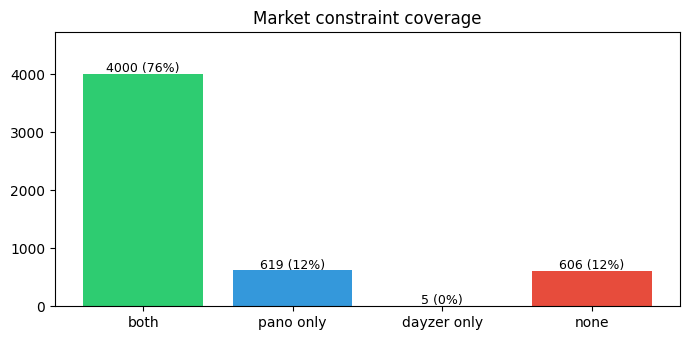

In [22]:
counts = [n_both,
          (res['pano_id'].notna() & res['dayzer_id'].isna()).sum(),
          (res['dayzer_id'].notna() & res['pano_id'].isna()).sum(),
          n_none]
labels = ['both', 'pano only', 'dayzer only', 'none']

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(labels, counts, color=['#2ecc71','#3498db','#e67e22','#e74c3c'])
for i, v in enumerate(counts):
    ax.text(i, v + 30, f'{v} ({v/N:.0%})', ha='center', fontsize=9)
ax.set_ylim(0, max(counts)*1.18)
ax.set_title('Market constraint coverage')
plt.tight_layout()
plt.savefig(DATA / 'coverage_chart.png', dpi=150)
plt.show()

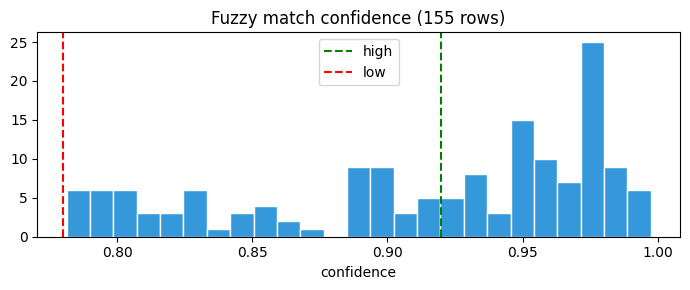

In [23]:
fuzzy = res[res['match_confidence'].notna() & (res['match_confidence'] < 1.0)]

fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(fuzzy['match_confidence'], bins=25, color='#3498db', edgecolor='white')
ax.axvline(0.92, color='green', ls='--', label='high')
ax.axvline(0.78, color='red',   ls='--', label='low')
ax.set_xlabel('confidence')
ax.set_title(f'Fuzzy match confidence ({len(fuzzy)} rows)')
ax.legend()
plt.tight_layout()
plt.savefig(DATA / 'confidence_distribution.png', dpi=150)
plt.show()

## Spot check

In [24]:
def ws(s):
    return re.sub(r'\s+', ' ', str(s)).strip().upper()

pairs = [
    ('ELIMA   138 KV  ELI-HAV1',     'L765.MARYSVILLE-SORENSON',       'ELIMA 138 KV ELI-HAV1'),
    ('94 HAURD-11323 11323 B 138 KV','L345.NELSON-ELECTRICJCT.15502',  '94 HAURD-11323'),
    ('EASTON  69 KV   EAS-EMU',      'ACTUAL',                          'EASTON 69 KV EAS-EMU'),
    ('GRACETON_230KVGRA-MANO_1_LN',  'L500.CONASTONE-PEACHBOTTOM.5012','GRACETON 230 KV GRA-MANO'),
]

for mf, mc, pf in pairs:
    row = market[market['CONSTRAINT'].apply(ws) == ws(mf)]
    if mc != 'ACTUAL':
        row = row[row['CONTINGENCY'].apply(ws).str.contains(ws(mc)[:12], na=False)]
    if row.empty:
        print(f"  ??? not in market : {mf}")
        continue
    mid = row.iloc[0]['market_id']
    out = res[res['market_id'] == mid]
    if out.empty or pd.isna(out.iloc[0]['pano_id']):
        print(f"  no pano match     : {mf}")
        continue
    matched = ws(out.iloc[0]['pano_facility'])
    ok = ws(pf) in matched
    print(f"  {'pass' if ok else 'check':5s} | {mf[:40]:<40} | {matched[:48]}")

  pass  | ELIMA   138 KV  ELI-HAV1                 | HAVILAND 138KV - ELIMA 138KV (ELIMA 138 KV ELI-H
  pass  | 94 HAURD-11323 11323 B 138 KV            | 94 HAURD-11323 11323 B 138 KV
  pass  | EASTON  69 KV   EAS-EMU                  | EASTON 69KV - EMUNI 69KV (EASTON 69 KV EAS-EMU)
  pass  | GRACETON_230KVGRA-MANO_1_LN              | MANOR 230KV - GRACETON 230KV (GRACETON 230 KV GR


## Lowest-confidence — eyeball these

In [25]:
(res[res['match_confidence'].notna() & (res['match_confidence'] < 1.0)]
   .sort_values('match_confidence')
   .head(20)
   [['market_constraint','market_contingency','pano_facility','pano_contingency','dayzer_name','match_confidence','match_method']]
   .reset_index(drop=True))

,market_constraint,market_contingency,pano_facility,pano_contingency,dayzer_name,match_confidence,match_method
0,COOLSPRI-MILFORD 23069 B 230 KV,L230.INDIANRIVER-MILFORD.23034,COOLSPRI-MILFORD COL-MIL A 230 KV,L230.IndianRiver-Milford.23034,NaN,0.781250,pano:fuzzy_low
1,CAYUGA3 - CAYUGA 345 KV L/O KANSAS - SUGAR CRE...,KANSAS - SUGAR CREEK 345 KV,CAYUGA3 345KV - CAYUGA2 345KV (CAYUGA2 345 KV ...,Kansas - Sugar Creek 345 kV,CAYUGA2_345 KV_CAY-CAY2:Kansas - Sugar Creek 3...,0.782609,pano:fuzzy_low;dayzer:fuzzy_low
2,15518-132 GARDEN 15518 2 138 KV L/O CORDOVA-SU...,L345.940CORDOVA-SUB39,15518 138KV - 132 GARD 138KV (15518 138 KV 155...,L345.940Cordova-Sub39,15518_138 KV_15518 2:L345.940Cordova-Sub39,0.784314,pano:fuzzy_low;dayzer:fuzzy_low
3,FLSCHURC-GLCARLYN 251B B 230 KV,L230.PLEASNTVIEW-EDWARDSFERRY-DICKERSON.23111/...,GLCARLYN 230KV - FLSCHURC 230KV (FLSCHURC 230 ...,L230.PleasntView-EdwardsFerry-Dickerson.23111/...,FLSCHURC_230 KV_251B:L230.PleasntView-EdwardsF...,0.784314,pano:fuzzy_low;dayzer:fuzzy_low
4,143 WOLF TR81CT-S XFORMER L 1 KV,345L11124 ELECTRIC JCT-LOMBARD 345 KV LINE,143 WOLF 1KV - 143 WOLF 138KV (143 WOLF 138 KV...,345L11124 Electric Jct-Lombard 345 kV Line,143 WOLF_138 KV_TR81CT-S:345L11124 Electric Jc...,0.785714,pano:fuzzy_low;dayzer:fuzzy_low
5,LICKRUN -ROCKWOOD LIC-ROC A 115 KV,L115.ROCKWOOD-SOMERSET,LICKRUN 115KV - ROCKWOOD 115KV (LICKRUN 115 KV...,L115.Rockwood-Somerset,LICKRUN_115 KV_LIC-ROC:L115.Rockwood-Somerset,0.785714,pano:fuzzy_low;dayzer:fuzzy_low
6,BAYSHORE TR1 345/138 KV L/O FOSTORIACENTRAL-LA...,L345.FOSTORIACENTRAL-LALLENDORF,BAYSHOR2 4.2KV - BAYSHOR2 138KV (BAYSHOR2 138 ...,L345.FostoriaCentral-Lallendorf,NaN,0.790698,pano:fuzzy_low
7,GOOSECRE TX1 XFORMER H 500 KV,500/230.PLEASANTVIEW.T3,GOOSECRE 500KV - GOOSECRE 230KV (GOOSECRE 500 ...,500/230.PleasantView.T3,GOOSECRE_500 KV_TX1:500/230.PleasantView.T3,0.791667,pano:fuzzy_low;dayzer:fuzzy_low
8,GOOSECRE TX1 XFORMER H 500 KV,L230.BELMONT-STONEWATER.2178,GOOSECRE 500KV - GOOSECRE 230KV (GOOSECRE 500 ...,L230.Belmont-Stonewater.2178,GOOSECRE_500 KV_TX1:L230.Belmont-Stonewater.2178,0.791667,pano:fuzzy_low;dayzer:fuzzy_low
9,GOOSECRE TX1 XFORMER H 500 KV,L230.BEAUMEAD-ASHBURN-PLEASANTVIEW.274,GOOSECRE 500KV - GOOSECRE 230KV (GOOSECRE 500 ...,L230.Beaumead-Ashburn-PleasantView.274,GOOSECRE_500 KV_TX1:L230.Beaumead-Ashburn-Plea...,0.791667,pano:fuzzy_low;dayzer:fuzzy_low
